In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
sns.set_style('whitegrid')
%matplotlib inline

In [54]:
df = sns.load_dataset('titanic')

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (891, 15)

Первые 5 строк:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [55]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [56]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Пропуски в признаках:")
print(missing)

Пропуски в признаках:
deck           688
age            177
embarked         2
embark_town      2
dtype: int64


In [57]:
# Создаем копию для работы
data = df.copy()

target = 'survived'

columns_to_drop = ['alive', 'deck', 'embark_town', 'who', 'adult_male', 'class']
data.drop(columns=[col for col in columns_to_drop if col in data.columns], inplace=True)

print("Признаки после удаления дублей:")
print(data.columns.tolist())

Признаки после удаления дублей:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [58]:
# Age - медианой по полу и классу
data['age'] = data.groupby(['sex', 'pclass'])['age'].transform(lambda x: x.fillna(x.median()))

# Embarked - модой (осталось 2 пропуска)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

# Проверяем, что пропусков нет
print("Пропуски после заполнения:")
print(data.isnull().sum())

Пропуски после заполнения:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [59]:
# Преобразуем 'sex' в числа
data['sex'] = data['sex'].map({'male': 1, 'female': 0})

# Преобразуем 'alone' (bool) в int
if 'alone' in data.columns:
    data['alone'] = data['alone'].astype(int)

# One-hot encoding для 'embarked'
data = pd.get_dummies(data, columns=['embarked'], prefix='emb', drop_first=False)

# Проверяем, что нет строковых колонок
print("\nТипы данных после кодирования:")
print(data.dtypes)


Типы данных после кодирования:
survived      int64
pclass        int64
sex           int64
age         float64
sibsp         int64
parch         int64
fare        float64
alone         int64
emb_C          bool
emb_Q          bool
emb_S          bool
dtype: object


In [60]:
X = data.drop(target, axis=1)
y = data[target]

print(f"Признаки: {X.shape}")
print(f"Целевая переменная: {y.shape}")
print(f"\nБаланс классов:\n{y.value_counts(normalize=True)}")

Признаки: (891, 10)
Целевая переменная: (891,)

Баланс классов:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Размеры выборок:")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

Размеры выборок:
Обучающая выборка: (712, 10)
Тестовая выборка: (179, 10)

Распределение классов в обучающей выборке:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [63]:
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier

# Создаем словарь с моделями
models = {
    'Bagging (Decision Tree)': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

In [67]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    """
    Обучает модель и возвращает метрики качества
    """
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Вычисление метрик
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    return metrics, model, y_pred, y_pred_proba

# Обучение всех моделей
results = []
trained_models = {}


for name, model in models.items():
    metrics, trained_model, y_pred, y_pred_proba = train_and_evaluate(
        model, X_train, X_test, y_train, y_test, name
    )
    results.append(metrics)
    trained_models[name] = trained_model


In [68]:
# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("\n" + "="*60)
print("СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ")
print("="*60)
print(results_df.round(4))


СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ
                         Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                  
Bagging (Decision Tree)    0.8045     0.8400  0.6087    0.7059   0.8485
Random Forest              0.7877     0.7818  0.6232    0.6935   0.8314
Extra Trees                0.7933     0.8077  0.6087    0.6942   0.8531
AdaBoost                   0.7821     0.7500  0.6522    0.6977   0.8252
Gradient Boosting          0.7933     0.7963  0.6232    0.6992   0.8235


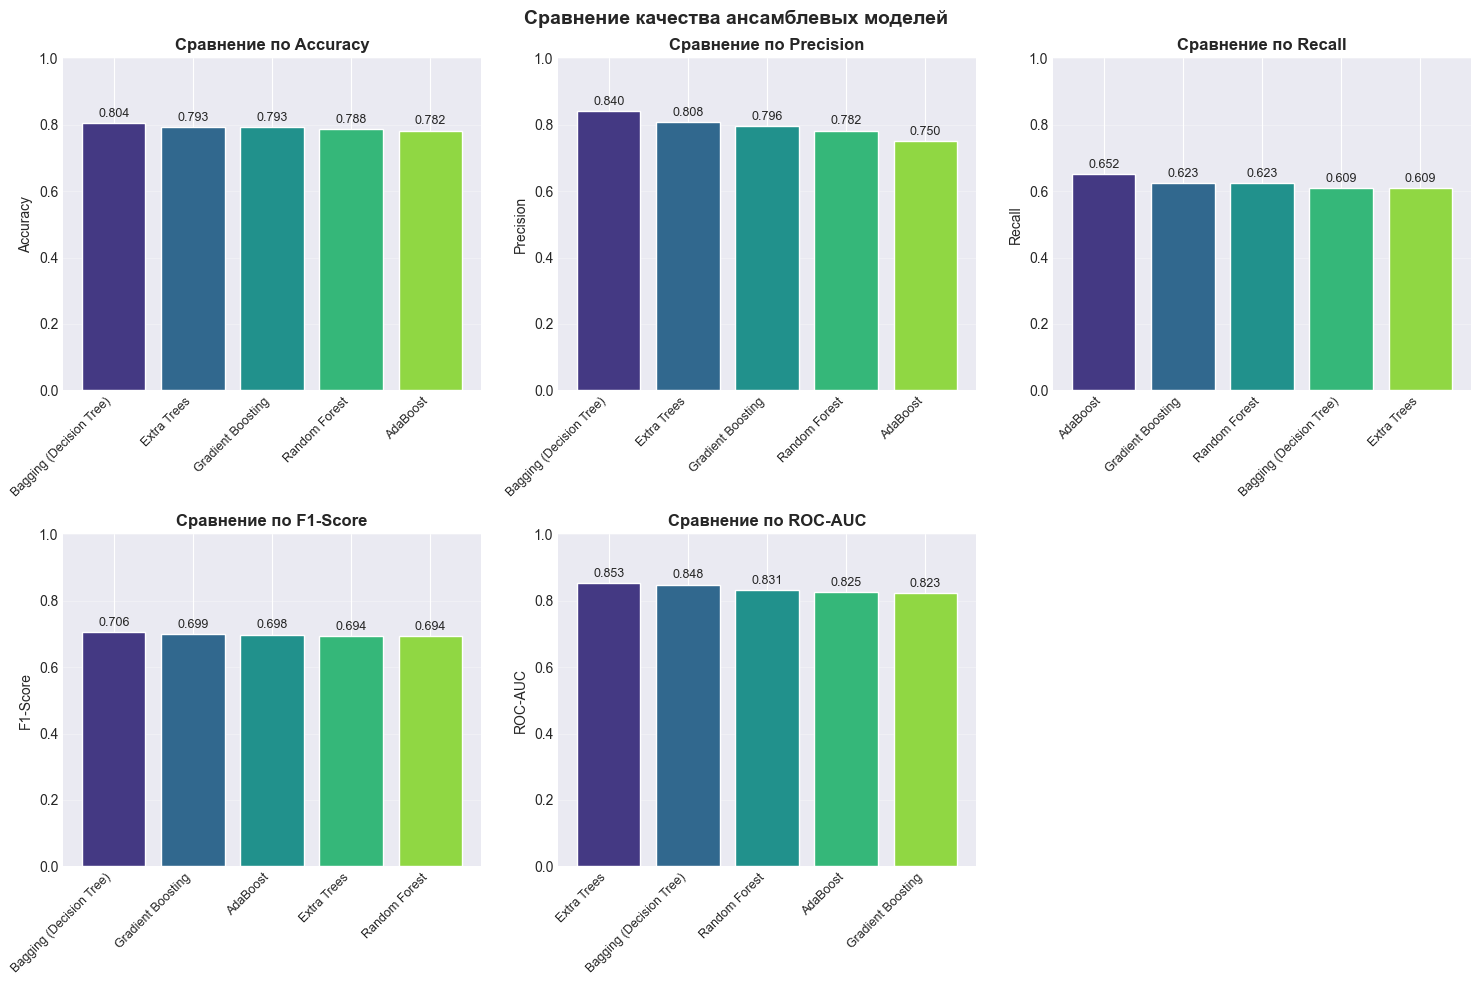

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# Сравнение по метрикам
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for i, metric in enumerate(metrics_to_plot):
    # Сортируем для красивого отображения
    sorted_data = results_df.sort_values(metric, ascending=False)
    
    bars = axes[i].bar(range(len(sorted_data)), sorted_data[metric], 
                       color=sns.color_palette("viridis", len(sorted_data)))
    axes[i].set_title(f'Сравнение по {metric}', fontsize=12, fontweight='bold')
    axes[i].set_xticks(range(len(sorted_data)))
    axes[i].set_xticklabels(sorted_data.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, sorted_data[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# Удаляем лишний график
fig.delaxes(axes[5])

plt.suptitle('Сравнение качества ансамблевых моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
# Находим лучшую модель по F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
best_f1 = results_df.loc[best_model_name, 'F1-Score']

print("="*60)
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print("="*60)
print(f"F1-Score: {best_f1:.4f}")
print(f"ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")

ЛУЧШАЯ МОДЕЛЬ: Bagging (Decision Tree)
F1-Score: 0.7059
ROC-AUC: 0.8485
Accuracy: 0.8045
